In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import multiprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, confusion_matrix, precision_score, recall_score, f1_score

In [4]:
pd.options.display.max_columns = None

In [2]:
Despob1acion = pd.read_csv('/home/dsc/Python/Despoblacion/Analisis_Preliminar_Variables/Despoblacion.csv', dtype='object')

In [3]:
Despob1acion.head()

,Nombre Provincia,Codigo Provincia,Nombre Municipio,Codigo Municipio,Poblacion Total,Poblacion Hombre,Poblacion Mujer,Superficie Km2,Densidad Poblacion,Altitud Municipios,...,5 personas,6 o más personas,Edad Media Edificios,Uso Industrial,Uso Residelcial,Uso Terciario,Otros Usos,Nº Hogares si Internet,Nº Hogares no Internet,Umbral
0,Albacete,02,Abengibre,02001,902.0,457.0,445.0,30.77,29.31,634.0,...,100,75,42.0,183.0,461.0,11.0,4.0,100,200,1
1,Albacete,02,Albacete,02003,171390.0,84288.0,87102.0,1126.99,152.08,681.0,...,16345,8765,26.0,40004.0,82879.0,7400.0,141.0,37410,25570,1
2,Albacete,02,Albatana,02004,794.0,403.0,391.0,30.5,26.03,582.0,...,105,55,52.0,80.0,454.0,8.0,3.0,35,260,1
3,Albacete,02,Almansa,02009,25432.0,12631.0,12801.0,531.82,47.82,687.0,...,1190,640,29.0,5131.0,12230.0,587.0,33.0,5250,4405,1
4,Albacete,02,Alpera,02010,2438.0,1261.0,1177.0,178.47,13.66,852.0,...,310,30,41.0,234.0,1268.0,36.0,1.0,235,665,1


In [5]:
Columnas = Despob1acion.columns[4 : -1]
Despob1acion[Columnas] = Despob1acion[Columnas].astype('float64')
Despob1acion['Umbral'] = Despob1acion['Umbral'].astype('int64')

Se dividen los datos, entrenamiento y de test:

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
                                        Despob1acion.drop(['Nombre Provincia', 'Codigo Provincia', 
                                                   'Nombre Municipio', 'Codigo Municipio', 'Umbral'], 
                                                   axis = 1),
                                        Despob1acion['Umbral'],
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

Pipeline transforma las variables numéricas y column tranform para aplicar las transformaciones a las columnas correctas.  
Creamos un pipeline que combine el preprocesador con el clasificador

In [7]:
# Transformaciones para las variables numéricas
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

preprocessor = ColumnTransformer(
                    transformers=[
                        ('numeric', numeric_transformer, X_train.columns.to_list())],remainder='passthrough')

# Se combinan los pasos de preprocesado y el modelo en un mismo pipeline
pipe = Pipeline(steps =[('preprocessing', preprocessor),
                 ('modelo', MLPClassifier(solver = 'adam', max_iter= 2000))])

GridSearchCV es una clase disponible en scikit-learn que permite evaluar y seleccionar de forma sistemática los parámetros de un modelo utilizado la validación cruzada  
permiten seleccionar los parámetros más apropiado para un modelo y un conjunto de datos utilizando la técnica de validación cruzada.

In [8]:
param_distributions = {
    'modelo__hidden_layer_sizes': [(10), (20), (10, 10)],
    'modelo__alpha': np.logspace(-3, 3, 10),
    'modelo__learning_rate_init': [0.001, 0.01],
}

grid = RandomizedSearchCV(
        estimator  = pipe,
        param_distributions = param_distributions,
        n_iter = 50,
        n_jobs     = multiprocessing.cpu_count() - 1,
        cv = 3)

grid.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('numeric',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Poblacion '
                                                                                'Total',
                                                                                'Poblacion '
                                                                                'Hombre',
                                                                                'Poblacion '
                                                                                'Mujer',
                                                                                'Superficie '
                                                                                'Km2',
                                                                                'Densidad '
                                                                                'Poblacion',
                                                                                'Altitud '
                                                                                'Municipios',
                                                                                'Nacimientos',
                                                                                'Matrimonios',
                                                                                'Defunciones',
                                                                                'Regime...
                                                                                '-45 ', ...])])),
                                             ('modelo',
                                              MLPClassifier(max_iter=2000))]),
                   n_iter=50, n_jobs=1,
                   param_distributions={'modelo__alpha': array([1.00000000e-03, 4.64158883e-03, 2.15443469e-02, 1.00000000e-01,
       4.64158883e-01, 2.15443469e+00, 1.00000000e+01, 4.64158883e+01,
       2.15443469e+02, 1.00000000e+03]),
                                        'modelo__hidden_layer_sizes': [10, 20,
                                                                       (10,
                                                                        10)],
                                        'modelo__learning_rate_init': [0.001,
                                                                       0.01]})

In [9]:
modelo_final = grid.best_estimator_
modelo_final

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Poblacion Total',
                                                   'Poblacion Hombre',
                                                   'Poblacion Mujer',
                                                   'Superficie Km2',
                                                   'Densidad Poblacion',
                                                   'Altitud Municipios',
                                                   'Nacimientos', 'Matrimonios',
                                                   'Defunciones',
                                                   'Regimen General',
                                                   'Regimen Agrario',
                                                   'Regimen Mar',
                                                   'Regim...
                                                   'Contratos iniciales '
                                                   'indefinidos mujeres',
                                                   'Contratos iniciales '
                                                   'temporales mujeres',
                                                   'Contratos convertidos en '
                                                   'indefinidos mujeres',
                                                   'Contratos  Agricultura',
                                                   'Contratos  Industria',
                                                   'Contratos Construcción',
                                                   'Contratos  Servicios',
                                                   'Total Paro Registrado',
                                                   'Paro hombre edad < 25',
                                                   'Paro hombre edad 25 -45 ', ...])])),
                ('modelo',
                 MLPClassifier(alpha=0.001, hidden_layer_sizes=20,
                               max_iter=2000))])

In [10]:
predicciones = modelo_final.predict(X_test)

In [11]:
RMSE = mean_squared_error(y_test, predicciones)
RMSE=str(round(RMSE, 4))
print('RMSE: ', RMSE)

cm = confusion_matrix(y_test, predicciones)
print('Matriz confusion: ', cm )
tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()
print(tn,fp,fn,tp)

precision = precision_score(y_test, predicciones)
precision=str(round(precision, 4))
print('Precision: ', precision )

recall = recall_score(y_test, predicciones)
recall=str(round(recall, 4))
print('Recall: ', recall )

f1 = f1_score(y_test, predicciones)
f1=str(round(f1, 4))
print('f1: ', f1 )

RMSE:  0.0678
Matriz confusion:  [[  6  49]
 [  5 737]]
6 49 5 737
Precision:  0.9377
Recall:  0.9933
f1:  0.9647


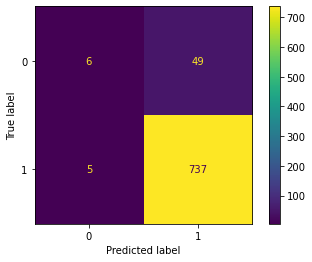

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicciones, labels = grid.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                          display_labels = grid.classes_)

disp.plot()

plt.show()